---

# LESSON 23: STACKED BAR CHARTS

---

>---
>You can create a **stacked bar chart** by setting the **bottom** arguments for the second "stacked" series as the values from the bars below it.
>
>- This will use those values as the baseline for the stacked bars instead of the x-axis.
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../Data/housing_data.csv').dropna().reset_index(drop=True)
df.head(3)

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,"Johnson County, TX",2019-09-23,2019-12-15,577.0,717.0,778.0,63.0,268737.6,17.095583
1,"Holmes County, OH",2017-10-09,2017-12-31,22.0,52.0,54.0,109.4,115308.3,34.050000
2,"Madison County, FL",2017-01-09,2017-04-02,12.0,54.0,55.0,151.2,158062.5,38.300000


In [3]:
df = df[(df.region_name.str.endswith('OR')) | (df.region_name.str.endswith('CA'))]

df = df.assign(state = df.region_name.str[-2:])
df.head(3)

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply,state
4,"Sacramento County, CA",2020-06-22,2020-09-13,5107.0,1729.0,2206.0,27.5,445540.9,5.235794,CA
24,"Gilliam County, OR",2018-06-18,2018-09-09,3.0,9.0,9.0,95.6,143037.5,9.000000,OR
155,"Nevada County, CA",2018-09-03,2018-11-25,529.0,480.0,517.0,71.4,557508.3,12.165607,CA


In [4]:
conditions = [
    (df.median_active_list_price > 600000),
    (df.median_active_list_price > 400000) & (df.median_active_list_price <= 600000),
    # (df.median_active_list_price <= 400000)
]

choices = ['600k+', '400k-600k']

df['price_range'] = np.select(condlist=conditions, choicelist=choices, default='0-400k')
df

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply,state,price_range
4,"Sacramento County, CA",2020-06-22,2020-09-13,5107.0,1729.0,2206.0,27.5,445540.9,5.235794,CA,400k-600k
24,"Gilliam County, OR",2018-06-18,2018-09-09,3.0,9.0,9.0,95.6,143037.5,9.000000,OR,0-400k
155,"Nevada County, CA",2018-09-03,2018-11-25,529.0,480.0,517.0,71.4,557508.3,12.165607,CA,400k-600k
164,"Malheur County, OR",2020-12-14,2021-03-07,38.0,45.0,48.0,57.6,245637.4,19.921212,OR,0-400k
174,"Sherman County, OR",2020-04-06,2020-06-28,1.0,2.0,2.0,65.7,251375.0,2.000000,OR,0-400k
...,...,...,...,...,...,...,...,...,...,...,...
560814,"Coos County, OR",2019-08-19,2019-11-10,263.0,251.0,271.0,66.7,280333.3,13.368411,OR,0-400k
560822,"Josephine County, OR",2021-06-14,2021-09-05,336.0,221.0,249.0,34.5,472447.6,9.279717,OR,400k-600k
560830,"Linn County, OR",2020-12-21,2021-03-14,333.0,204.0,234.0,36.5,321820.8,9.217346,OR,0-400k
560899,"San Joaquin County, CA",2017-05-22,2017-08-13,2095.0,1282.0,1479.0,34.9,354895.7,8.692168,CA,0-400k


In [5]:
df_plot = (df
    .pivot_table(index='price_range', columns='state', 
                 values='total_homes_sold', aggfunc='sum')
    .round())
df_plot

state,CA,OR
price_range,,
0-400k,4680069.0,1372079.0
400k-600k,4733013.0,2429844.0
600k+,15183038.0,246111.0


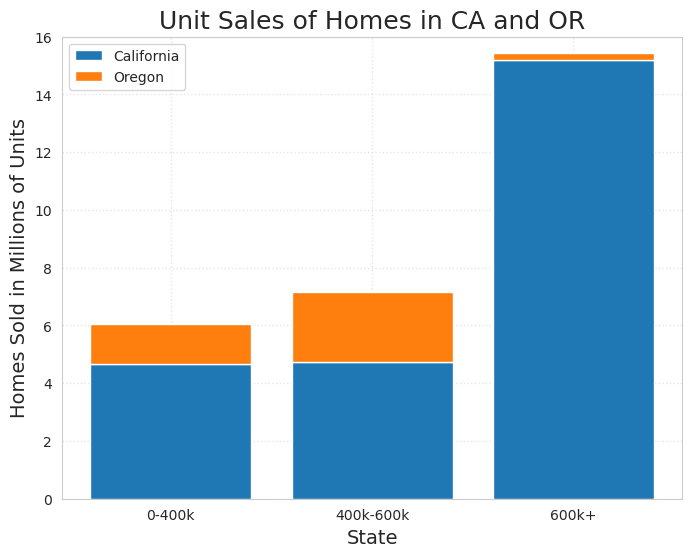

In [6]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.bar(df_plot.index, df_plot['CA']/1e6, 
       label='California')

ax.bar(df_plot.index, df_plot['OR']/1e6, 
       label='Oregon', bottom=df_plot['CA']/1e6)

ax.set_title('Unit Sales of Homes in CA and OR', fontsize=18)
ax.set_xlabel('State', fontsize=14)
ax.set_ylabel('Homes Sold in Millions of Units', fontsize=14)

ax.set_ylim(0, 16)

ax.legend(loc='upper left')
ax.grid(axis='both', alpha=0.5,
        ls=':', linewidth=1)
plt.show()

<br><br>

# 100% STACKED BAR CHARTS


>---
>
>To create a **100% stacked bar chart**, convert your DataFrame to row-level percentages before plotting.
>
>---

In [9]:
df_plot2 = df_plot.copy()

df_plot2 = df_plot2.apply(lambda x: (x*100 / sum(x)), axis=1)
df_plot2

state,CA,OR
price_range,,
0-400k,77.329057,22.670943
400k-600k,66.077167,33.922833
600k+,98.404896,1.595104


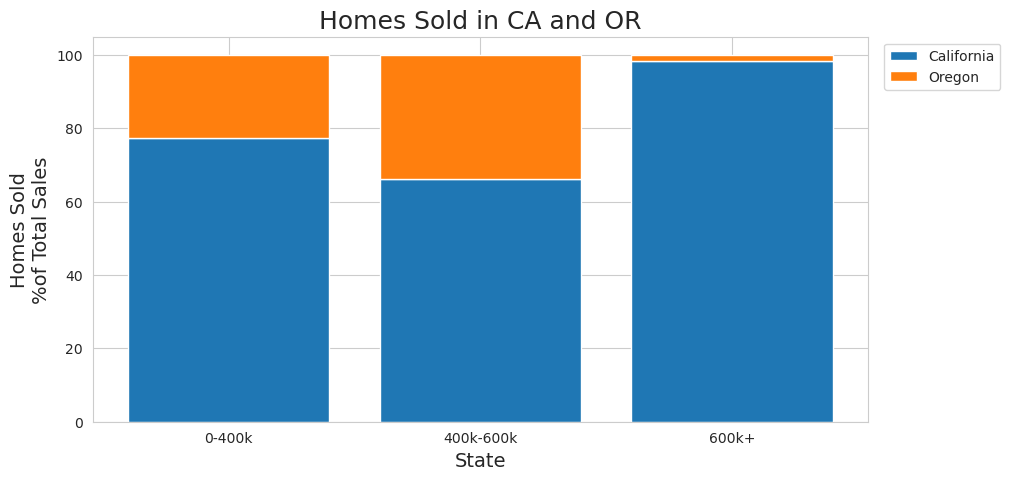

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

ax.bar(df_plot2.index, df_plot2['CA'], 
       label='California')

ax.bar(df_plot2.index, df_plot2['OR'],
       label='Oregon', bottom=df_plot2['CA'])

ax.set_title('Homes Sold in CA and OR', fontsize=18)
ax.set_xlabel('State', fontsize=14)
ax.set_ylabel('Homes Sold\n%of Total Sales', fontsize=14)

ax.legend(bbox_to_anchor=(1.18, 1))
plt.show()

<br><br>

---

## LABORATORY

In [12]:
df = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna().reset_index(drop=True)
df.head()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,"Johnson County, TX",2019-09-23,2019-12-15,577.0,717.0,778.0,63.0,268737.6,17.095583
1,"Holmes County, OH",2017-10-09,2017-12-31,22.0,52.0,54.0,109.4,115308.3,34.050000
2,"Madison County, FL",2017-01-09,2017-04-02,12.0,54.0,55.0,151.2,158062.5,38.300000
3,"Barry County, MO",2020-11-23,2021-02-14,79.0,70.0,77.0,82.8,196509.1,13.157870
4,"Sacramento County, CA",2020-06-22,2020-09-13,5107.0,1729.0,2206.0,27.5,445540.9,5.235794


In [13]:
df.median_active_list_price.max()

np.float64(875005248.2)

In [14]:
df = (df
    .assign(price_range = pd.cut(x=df.median_active_list_price,
                                 bins=[0, 400000, 600000, 900000000],
                                 labels=['0-400k', '400k-600k', '600k+']),
            state = df.region_name.str[-2:])
)

df

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply,price_range,state
0,"Johnson County, TX",2019-09-23,2019-12-15,577.0,717.0,778.0,63.0,268737.6,17.095583,0-400k,TX
1,"Holmes County, OH",2017-10-09,2017-12-31,22.0,52.0,54.0,109.4,115308.3,34.050000,0-400k,OH
2,"Madison County, FL",2017-01-09,2017-04-02,12.0,54.0,55.0,151.2,158062.5,38.300000,0-400k,FL
3,"Barry County, MO",2020-11-23,2021-02-14,79.0,70.0,77.0,82.8,196509.1,13.157870,0-400k,MO
4,"Sacramento County, CA",2020-06-22,2020-09-13,5107.0,1729.0,2206.0,27.5,445540.9,5.235794,400k-600k,CA
...,...,...,...,...,...,...,...,...,...,...,...
560910,"Boulder County, CO",2018-01-15,2018-04-08,973.0,746.0,838.0,44.9,647883.0,10.992834,600k+,CO
560911,"Randolph County, MO",2019-03-11,2019-06-02,21.0,12.0,13.0,23.5,122793.7,9.219697,0-400k,MO
560912,"Sullivan County, IN",2018-03-05,2018-05-27,1.0,10.0,10.0,87.1,61741.6,10.000000,0-400k,IN
560913,"Clatsop County, OR",2019-06-03,2019-08-25,1.0,4.0,4.0,53.7,650000.0,4.000000,600k+,OR


In [15]:
fixed_date = pd.to_datetime('2021-08-01')

lab = (df
    .query("period_end == @fixed_date and state.isin(['CA', 'OR', 'WA'])").pivot_table(index='price_range', columns='state', 
                                                    values='inventory', aggfunc='sum', observed=False)
)
lab.head()

state,CA,OR,WA
price_range,,,
0-400k,4267.0,1074.0,2143.0
400k-600k,13877.0,4711.0,4858.0
600k+,35146.0,1228.0,3649.0


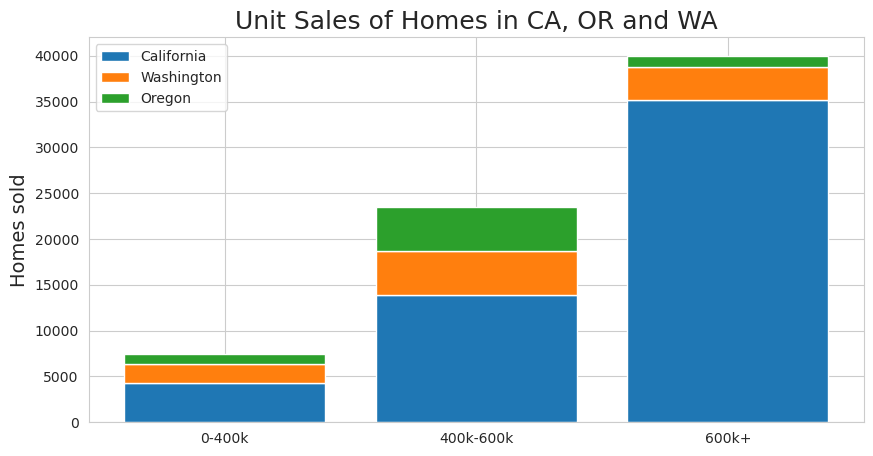

In [21]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

ax.bar(lab.index, lab.CA, label='California')
ax.bar(lab.index, lab.WA, label='Washington', bottom=lab.CA)
ax.bar(lab.index, lab.OR, label='Oregon', bottom=lab.CA + lab.WA)

ax.set_title('Unit Sales of Homes in CA, OR and WA', fontsize=18)
ax.set_ylabel('Homes sold', fontsize=14)

ax.legend()

plt.show()